<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Top%20250%20imdb%20movie%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Top 250 IMDB Movie Dataset

## Project Summary: Unveiling Insights from the IMDb Top 250 Movie Dataset

This project embarked on an exciting journey to explore, analyze, and build predictive and recommendation systems using the IMDb Top 250 movie dataset. From initial data inspection to advanced statistical tests and machine learning, we've uncovered several intriguing aspects of these highly-rated films.

### The Dataset at a Glance

The dataset provides core information about 250 top-ranked movies, including their `Rank`, `Title`, `Year` of release, `Duration_Minutes`, `Certificate`, and `Source`. A quick look revealed that the `Rating` column was entirely empty, so it was promptly removed. Interestingly, the `Source` column contained only one unique value ("IMDb Top 250"), indicating a consistent data origin and making it unsuitable for feature engineering.


### Statistical Deep Dive: Uncovering Distributions and Relationships

Our statistical analysis painted a clearer picture of the data:

*   **Movie Duration (`Duration_Minutes`)** emerged as a particularly interesting feature. While the average movie runs for about 131.5 minutes, its distribution is heavily skewed to the right, with a few exceptionally long films extending up to 374 minutes. This was visually confirmed by box plots, which also highlighted several potential outliers in movie lengths.
*   **Non-Normal Distributions**: Quantitative tests (Shapiro-Wilk) revealed that none of our numerical features (`Rank`, `Year`, `Duration_Minutes`) followed a normal distribution. This is a crucial insight, suggesting that statistical methods assuming normality might not be appropriate without data transformation.
*   **Certificate Matters for Duration**: A key finding from our ANOVA test was the statistically significant difference in mean movie durations across various `Certificate` categories (e.g., 'R', 'PG-13', 'G'). This implies that the classification of a movie directly relates to its typical runtime, with 'PG-13' films, for instance, tending to be longer on average.

### Feature Engineering and Machine Learning: A Learning Experience

To prepare the data for machine learning, we handled missing values in the `Certificate` column by imputing them with the mode ('R'). We then transformed this categorical column into numerical form using one-hot encoding. Features like `Title_Length`, `Word_Count`, and `Decade` were also extracted from existing columns. While a Random Forest Regressor model was trained to predict `Duration_Minutes` using `Year` and the encoded `Certificate` information, its performance was notably poor, indicated by a negative R-squared value. This clearly suggested that the chosen features alone were insufficient to accurately predict a movie's duration.

### Movie Recommendations: Finding Similar Titles

Despite the challenges in predicting duration, a movie recommender system was successfully built. This system leverages the `Title` of movies to find similar films based on text similarity. Given a movie title, it can suggest other top-ranked films that share similar naming conventions, providing a basic but functional recommendation capability.

### Moving Forward

This project highlights that while IMDb's top 250 list offers valuable data, predicting nuanced aspects like movie duration requires a richer set of features, possibly including genre, director, cast, or even plot summaries. The insights gained provide a solid foundation for future, more complex analyses aimed at deeper understanding and more robust predictive models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mafaqbhatti/top-250-imdb-movie-dataset

# Unziping the downloaded file
!unzip top-250-imdb-movie-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mafaqbhatti/top-250-imdb-movie-dataset
License(s): apache-2.0
  0% 0.00/4.55k [00:00<?, ?B/s]
100% 4.55k/4.55k [00:00<00:00, 14.5MB/s]
Archive:  top-250-imdb-movie-dataset.zip
  inflating: top_250_imdb_dataset.csv  


# Data Inspection

In [ ]:
df = pd.read_csv('top_250_imdb_dataset.csv')
df.head(11)

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
0,1,The Shawshank Redemption,1994,NaN,142,R,IMDb Top 250
1,2,The Godfather,1972,NaN,175,R,IMDb Top 250
2,3,The Dark Knight,2008,NaN,152,PG-13,IMDb Top 250
3,4,The Godfather Part II,1974,NaN,202,R,IMDb Top 250
4,5,12 Angry Men,1957,NaN,96,Approved,IMDb Top 250
5,6,The Lord of the Rings: The Return of the King,2003,NaN,201,PG-13,IMDb Top 250
6,7,Schindler's List,1993,NaN,195,R,IMDb Top 250
7,8,The Lord of the Rings: The Fellowship of the Ring,2001,NaN,178,PG-13,IMDb Top 250
8,9,Pulp Fiction,1994,NaN,154,R,IMDb Top 250
9,10,"The Good, the Bad and the Ugly",1966,NaN,178,R,IMDb Top 250


In [ ]:
df.tail(11)

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
239,240,The Passion of Joan of Arc,1928,NaN,114,Passed,IMDb Top 250
240,241,My Father and My Son,2005,NaN,112,Not Rated,IMDb Top 250
241,242,Marty Supreme,2025,NaN,149,R,IMDb Top 250
242,243,The Battle of Algiers,1966,NaN,121,Not Rated,IMDb Top 250
243,244,The Handmaiden,2016,NaN,145,Not Rated,IMDb Top 250
244,245,Network,1976,NaN,121,R,IMDb Top 250
245,246,To Be or Not to Be,1942,NaN,99,Approved,IMDb Top 250
246,247,The Grapes of Wrath,1940,NaN,129,Approved,IMDb Top 250
247,248,Gangs of Wasseypur,2012,NaN,321,Not Rated,IMDb Top 250
248,249,Drishyam,2015,NaN,163,Not Rated,IMDb Top 250


In [ ]:
df.shape

(250, 7)

In [ ]:
df.columns

Index(['Rank', 'Title', 'Year', 'Rating', 'Duration_Minutes', 'Certificate',
       'Source'],
      dtype='object')

In [ ]:
df.dtypes

,0
Rank,int64
Title,object
Year,int64
Rating,float64
Duration_Minutes,int64
Certificate,object
Source,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              250 non-null    int64  
 1   Title             250 non-null    object 
 2   Year              250 non-null    int64  
 3   Rating            0 non-null      float64
 4   Duration_Minutes  250 non-null    int64  
 5   Certificate       245 non-null    object 
 6   Source            250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Rank,250.0,NaN,NaN,NaN,125.5,72.312977,1.0,63.25,125.5,187.75,250.0
Title,250,250,The Shawshank Redemption,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,250.0,NaN,NaN,NaN,1988.62,25.552442,1921.0,1973.0,1995.0,2009.0,2025.0
Rating,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration_Minutes,250.0,NaN,NaN,NaN,131.516,35.747128,45.0,108.25,127.5,147.75,374.0
Certificate,245,8,R,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,250,1,IMDb Top 250,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Rank,0
Title,0
Year,0
Rating,250
Duration_Minutes,0
Certificate,5
Source,0


In [ ]:
df.drop('Rating', axis = 1, inplace = True)
df.isnull().sum()

,0
Rank,0
Title,0
Year,0
Duration_Minutes,0
Certificate,5
Source,0


# Multivariate Analysis


Analyzing relationships with Hue: Certificate...


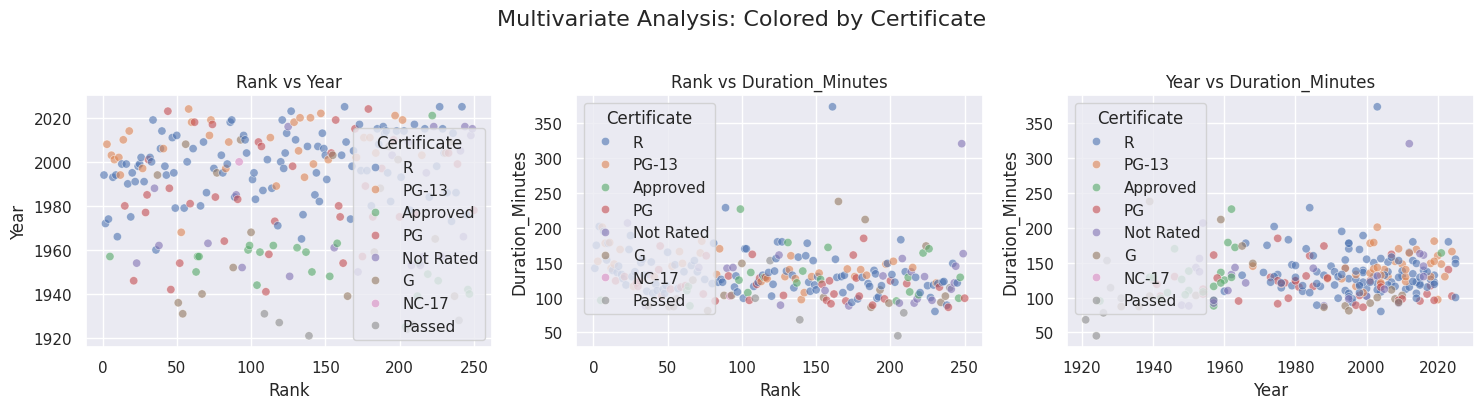


Analyzing relationships with Hue: Source...


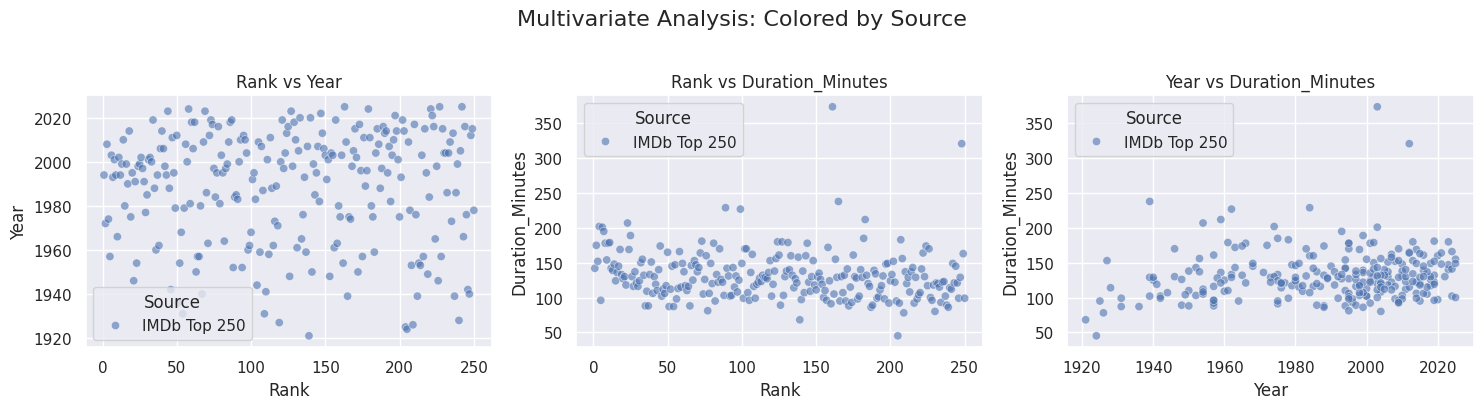

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Univariate Analysis

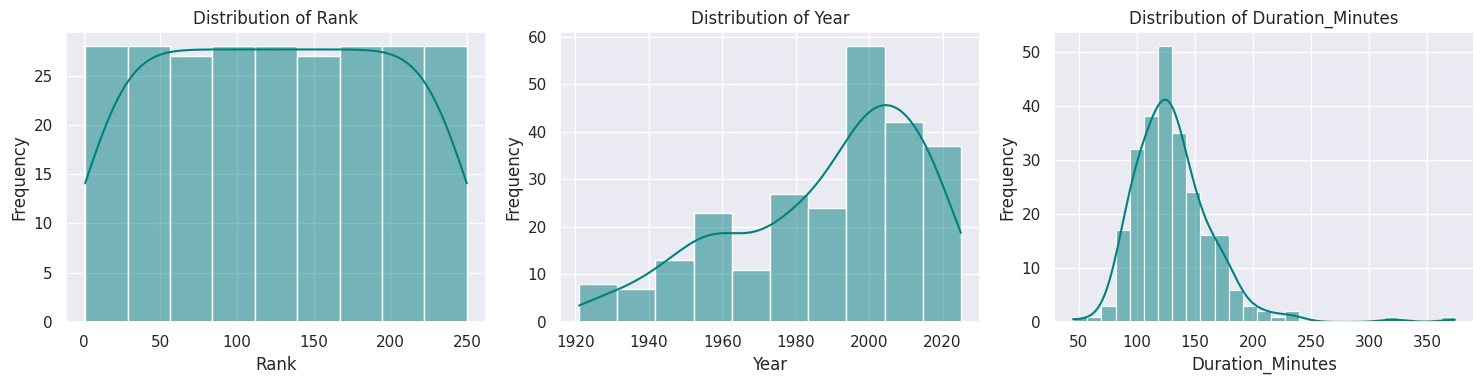

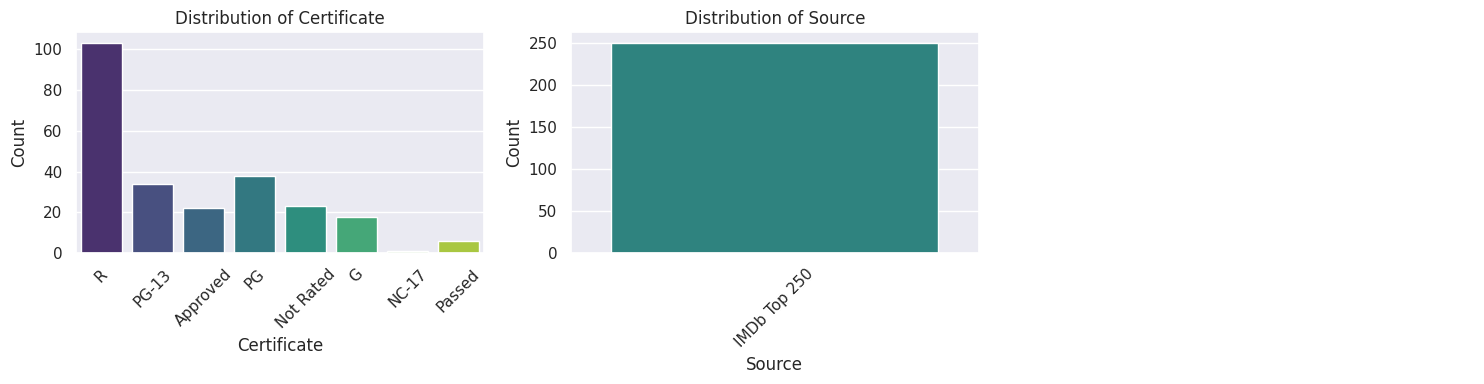

--- Categorical Value Counts ---

Value counts for Certificate:
Certificate
R            103
PG            38
PG-13         34
Not Rated     23
Approved      22
G             18
Passed         6
NC-17          1
Name: count, dtype: int64

Value counts for Source:
Source
IMDb Top 250    250
Name: count, dtype: int64


In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

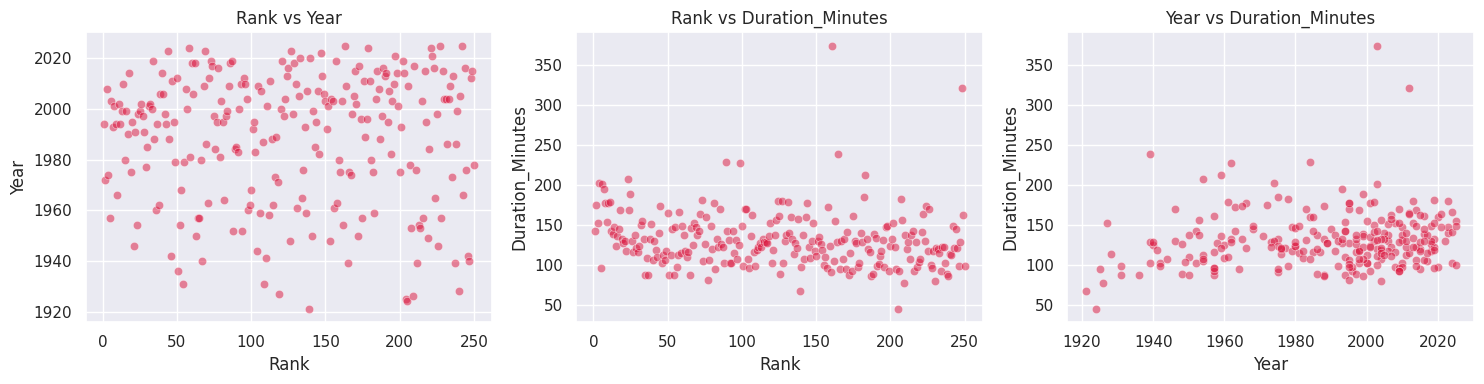

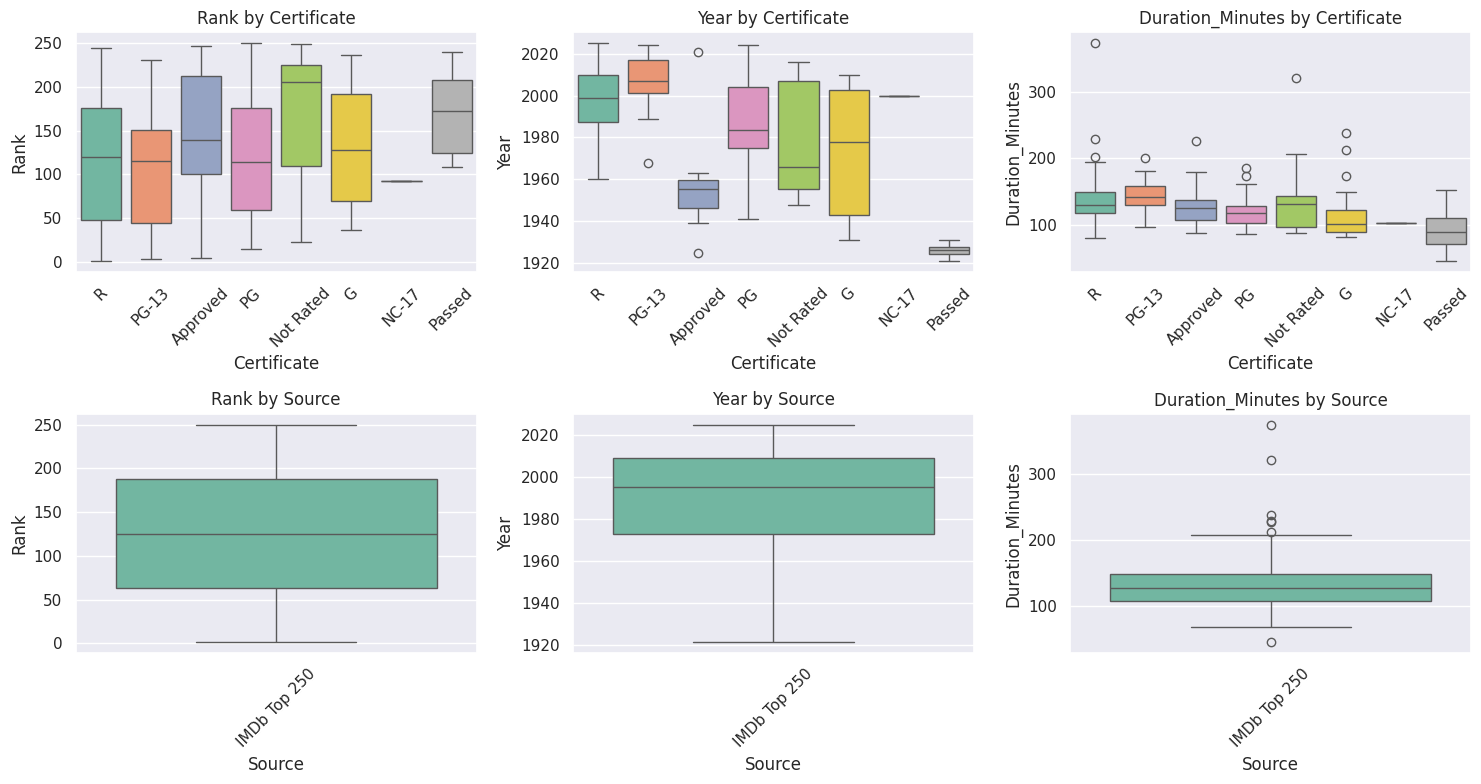

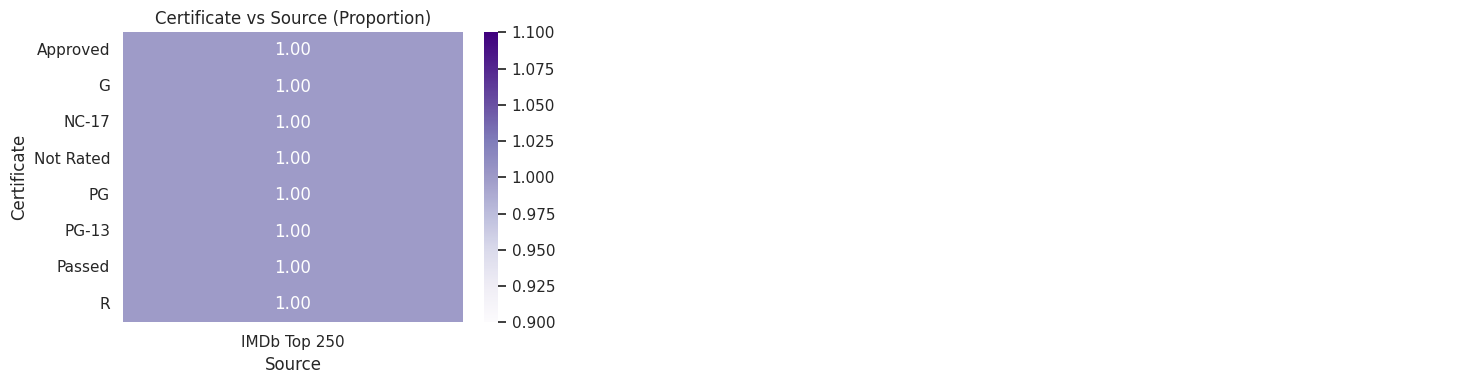

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensure axes is always an iterable of Axes objects
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else: # If it's a single Axes object (e.g., when num_rows=1, num_cols=1), wrap it in a list
        axes = [axes]

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

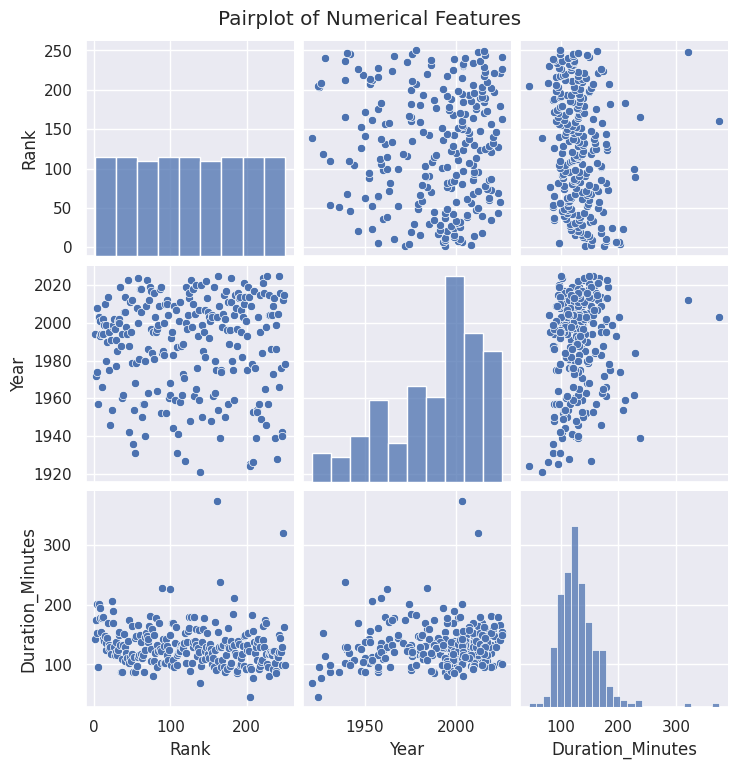

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

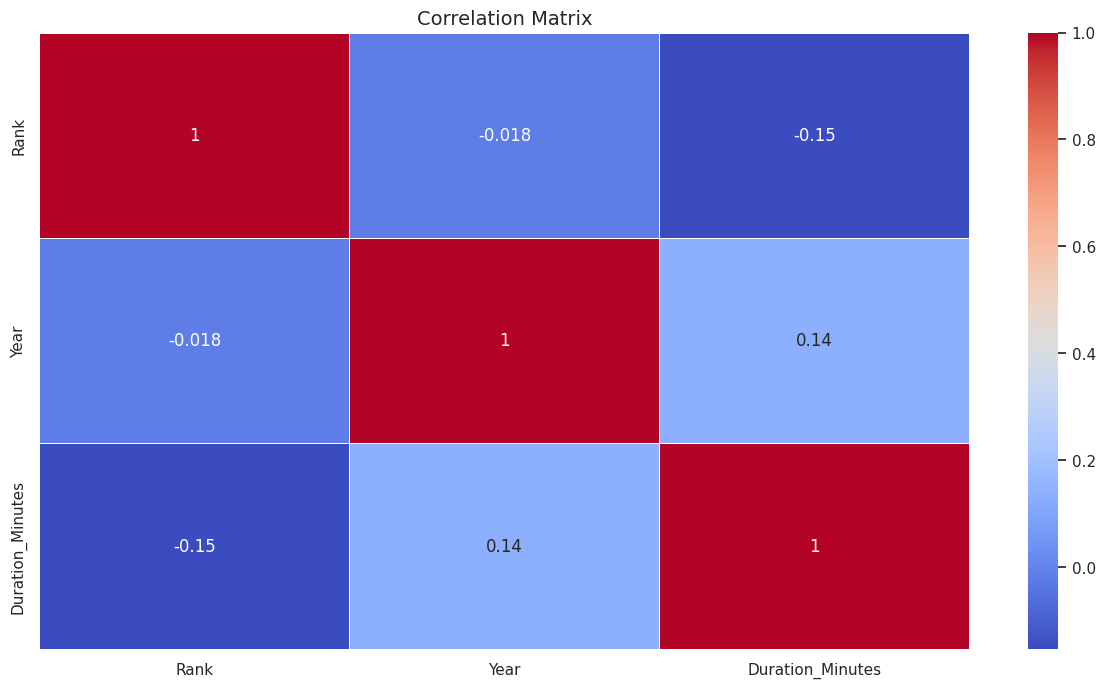

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

## Detailed Descriptive Statistics

Calculating and displaying enhanced descriptive statistics for all numerical columns, including measures of central tendency, dispersion, and shape (skewness, kurtosis). Also, exploring descriptive statistics for numerical features grouped by categorical features like 'Certificate' and 'Source'.


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

print("### Descriptive Statistics for Numerical Columns:\n")
print(df[numerical_cols].describe())

print("\n### Skewness for Numerical Columns:\n")
print(df[numerical_cols].skew())

print("\n### Kurtosis for Numerical Columns:\n")
print(df[numerical_cols].kurt())

print("\n### Descriptive Statistics Grouped by 'Certificate':\n")
print(df.groupby('Certificate')[numerical_cols].describe())

print("\n### Descriptive Statistics Grouped by 'Source':\n")
print(df.groupby('Source')[numerical_cols].describe())

### Descriptive Statistics for Numerical Columns:

             Rank         Year  Duration_Minutes
count  250.000000   250.000000        250.000000
mean   125.500000  1988.620000        131.516000
std     72.312977    25.552442         35.747128
min      1.000000  1921.000000         45.000000
25%     63.250000  1973.000000        108.250000
50%    125.500000  1995.000000        127.500000
75%    187.750000  2009.000000        147.750000
max    250.000000  2025.000000        374.000000

### Skewness for Numerical Columns:

Rank                0.000000
Year               -0.715405
Duration_Minutes    2.175812
dtype: float64

### Kurtosis for Numerical Columns:

Rank                -1.200000
Year                -0.418925
Duration_Minutes    10.796763
dtype: float64

### Descriptive Statistics Grouped by 'Certificate':

              Rank                                                       \
             count        mean        std    min     25%    50%     75%   
Certificate         

## Outlier Detection and Visualization

Identifying and visualizing potential outliers in numerical columns using box plots. This will help understand the range and spread of the data and any extreme values.


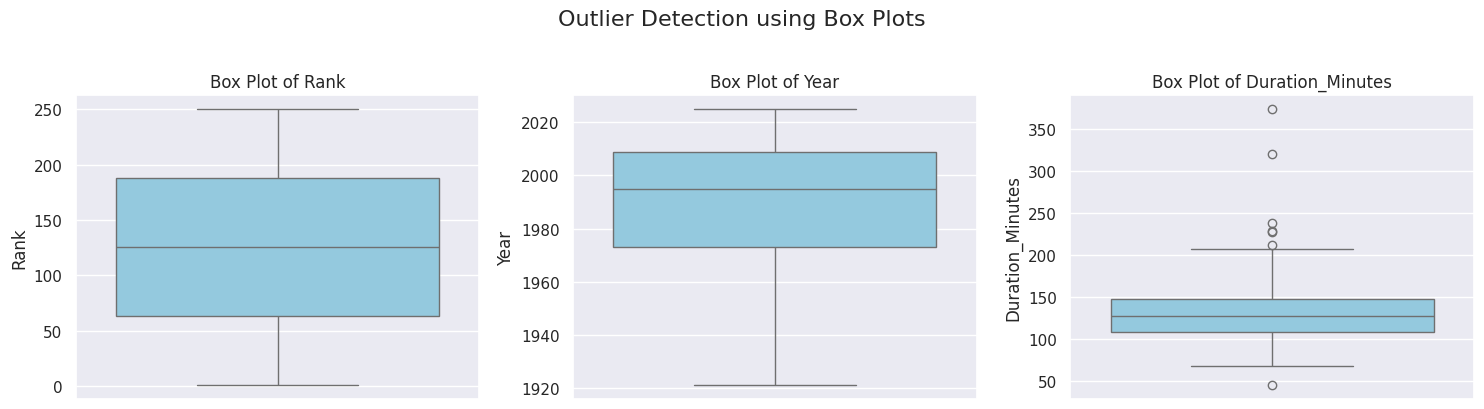

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Outlier Detection using Box Plots', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for outlier detection.")

In [ ]:
print("----> Quantitative Assessment of Numerical Column Distributions")
print("\nSkewness for Numerical Columns:")
print(df[numerical_cols].skew())
print("\nKurtosis for Numerical Columns:")
print(df[numerical_cols].kurt())

----> Quantitative Assessment of Numerical Column Distributions

Skewness for Numerical Columns:
Rank                0.000000
Year               -0.715405
Duration_Minutes    2.175812
dtype: float64

Kurtosis for Numerical Columns:
Rank                -1.200000
Year                -0.418925
Duration_Minutes    10.796763
dtype: float64


## Distribution Analysis for Numerical Features

Quantitatively assess the distribution characteristics of numerical columns, including skewness and kurtosis values, to understand their symmetry and tail-heaviness. Additionally, applying appropriate statistical tests for normality if necessary.


In [ ]:
from scipy.stats import shapiro

numerical_cols = df.select_dtypes(include=np.number).columns

print("\n### Shapiro-Wilk Test for Normality")
for col in numerical_cols:
    stat, p = shapiro(df[col])
    print(f"\nColumn: {col}")
    print(f"  Test Statistic: {stat:.4f}")
    print(f"  P-value: {p:.4f}")
    if p < 0.05:
        print(f"  Conclusion: Reject null hypothesis. The data in '{col}' is not normally distributed.")
    else:
        print(f"  Conclusion: Fail to reject null hypothesis. The data in '{col}' appears to be normally distributed.")


### Shapiro-Wilk Test for Normality

Column: Rank
  Test Statistic: 0.9546
  P-value: 0.0000
  Conclusion: Reject null hypothesis. The data in 'Rank' is not normally distributed.

Column: Year
  Test Statistic: 0.9319
  P-value: 0.0000
  Conclusion: Reject null hypothesis. The data in 'Year' is not normally distributed.

Column: Duration_Minutes
  Test Statistic: 0.8635
  P-value: 0.0000
  Conclusion: Reject null hypothesis. The data in 'Duration_Minutes' is not normally distributed.


## ANOVA Test for 'Duration_Minutes' across 'Certificate' Categories

Performing an ANOVA (Analysis of Variance) test to determine if there are statistically significant differences in the mean 'Duration_Minutes' across different 'Certificate' categories. State the null and alternative hypotheses, execute the ANOVA test, and interpret the p-value.

### Hypotheses for ANOVA Test

**Null Hypothesis (H0):** There is no significant difference in the mean 'Duration_Minutes' across the different 'Certificate' categories.

**Alternative Hypothesis (H1):** There is a significant difference in the mean 'Duration_Minutes' for at least one 'Certificate' category compared to the others.

In [ ]:
from scipy.stats import f_oneway

# Filter out Certificate categories with NaN values for Duration_Minutes
df_anova = df.dropna(subset=['Certificate', 'Duration_Minutes'])

# Get unique Certificate categories
categories = df_anova['Certificate'].unique()

# Create a list of 'Duration_Minutes' for each category
data_for_anova = [df_anova['Duration_Minutes'][df_anova['Certificate'] == cat] for cat in categories]

# Perform ANOVA test
f_statistic, p_value = f_oneway(*data_for_anova)

print("### ANOVA Test Results")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is less than alpha ({alpha}), we reject the null hypothesis.\nThis indicates that there is a statistically significant difference in the mean 'Duration_Minutes' across different 'Certificate' categories.")
else:
    print(f"Conclusion: Since the p-value ({p_value:.4f}) is greater than alpha ({alpha}), we fail to reject the null hypothesis.\nThis indicates that there is no statistically significant difference in the mean 'Duration_Minutes' across different 'Certificate' categories.")

### ANOVA Test Results
F-statistic: 3.1299
P-value: 0.0035
Conclusion: Since the p-value (0.0035) is less than alpha (0.05), we reject the null hypothesis.
This indicates that there is a statistically significant difference in the mean 'Duration_Minutes' across different 'Certificate' categories.


# Building Movie Recommender

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

print("--- 1. PREPARING DATA FOR RECOMMENDATION ---")
# We will use the 'Title' column for recommendations, as 'Genre' and 'Directors' are not available.

# Create a "Soup" column (all keywords mixed together)
def create_soup(x):
    return str(x['Title']).lower()

# Assuming 'Title' column is always present and used as the primary feature
if 'Title' in df.columns:
    df['soup'] = df.apply(create_soup, axis=1)
    print("✅ Created 'soup' column from 'Title' for recommendations.")

    # 2. Vectorize the Text (Convert words to numbers)
    count = CountVectorizer(stop_words='english')
    count_matrix = count.fit_transform(df['soup'])

    # 3. Calculate Similarity (The Math)
    cosine_sim = cosine_similarity(count_matrix, count_matrix)
    print("✅ Calculated Cosine Similarity Matrix.")

    # 4. Recommendation Function
    # Reset index to ensure we can look up movies by number
    df = df.reset_index(drop=True)
    indices = pd.Series(df.index, index=df['Title']).drop_duplicates()

    def get_recommendations(title, cosine_sim=cosine_sim):
        # Get the index of the movie that matches the title
        if title not in indices:
            return f"Movie '{title}' not found in Top 250."

        idx = indices[title]

        # Get the pairwise similarity scores of all movies with that movie
        sim_scores = list(enumerate(cosine_sim[idx]))

        # Sort the movies based on the similarity scores
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Get the scores of the 5 most similar movies
        sim_scores = sim_scores[1:6]

        # Get the movie indices
        movie_indices = [i[0] for i in sim_scores]

        # Return the top 5 most similar movies
        return df['Title'].iloc[movie_indices]

    # Test it!
    test_movie = df['Title'].iloc[0] # The #1 movie (usually Shawshank Redemption)
    print(f"\n🎥 Recommendation Test: Because you watched '{test_movie}'...")
    print(get_recommendations(test_movie))

else:
    print("❌ 'Title' column missing. Cannot build recommender.")


--- 1. PREPARING DATA FOR RECOMMENDATION ---
✅ Created 'soup' column from 'Title' for recommendations.
✅ Calculated Cosine Similarity Matrix.

🎥 Recommendation Test: Because you watched 'The Shawshank Redemption'...
1                                    The Godfather
2                                  The Dark Knight
3                            The Godfather Part II
4                                     12 Angry Men
5    The Lord of the Rings: The Return of the King
Name: Title, dtype: object


## Feature Engineering: Handle Missing Values and Encode Categoricals

In [ ]:
certificate_mode = df['Certificate'].mode()[0]
print(f"The mode of the 'Certificate' column is: {certificate_mode}")

The mode of the 'Certificate' column is: R


In [ ]:
df['Certificate'].fillna(certificate_mode, inplace=True)
print("Missing values in 'Certificate' column filled with mode.")
print(df['Certificate'].isnull().sum())

Missing values in 'Certificate' column filled with mode.
0


In [ ]:
certificate_encoded = pd.get_dummies(df['Certificate'], prefix='Certificate', drop_first=True)
df = pd.concat([df, certificate_encoded], axis=1)
print("One-hot encoding applied to 'Certificate' column and new columns added to DataFrame.")
print(df.head())

One-hot encoding applied to 'Certificate' column and new columns added to DataFrame.
   Rank                     Title  Year  Duration_Minutes Certificate  \
0     1  The Shawshank Redemption  1994               142           R   
1     2             The Godfather  1972               175           R   
2     3           The Dark Knight  2008               152       PG-13   
3     4     The Godfather Part II  1974               202           R   
4     5              12 Angry Men  1957                96    Approved   

         Source  Certificate_G  Certificate_NC-17  Certificate_Not Rated  \
0  IMDb Top 250          False              False                  False   
1  IMDb Top 250          False              False                  False   
2  IMDb Top 250          False              False                  False   
3  IMDb Top 250          False              False                  False   
4  IMDb Top 250          False              False                  False   

   Certificate_PG  

In [ ]:
df.drop('Certificate', axis=1, inplace=True)
print("Original 'Certificate' column dropped from DataFrame.")
print(df.head())

Original 'Certificate' column dropped from DataFrame.
   Rank                     Title  Year  Duration_Minutes        Source  \
0     1  The Shawshank Redemption  1994               142  IMDb Top 250   
1     2             The Godfather  1972               175  IMDb Top 250   
2     3           The Dark Knight  2008               152  IMDb Top 250   
3     4     The Godfather Part II  1974               202  IMDb Top 250   
4     5              12 Angry Men  1957                96  IMDb Top 250   

   Certificate_G  Certificate_NC-17  Certificate_Not Rated  Certificate_PG  \
0          False              False                  False           False   
1          False              False                  False           False   
2          False              False                  False           False   
3          False              False                  False           False   
4          False              False                  False           False   

   Certificate_PG-13  Cert

# Machine Learning


In [ ]:
y = df['Duration_Minutes']
X = df[['Year'] + [col for col in df.columns if col.startswith('Certificate_')]]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Target variable 'y' and feature variables 'X' defined.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Target variable 'y' and feature variables 'X' defined.
X_train shape: (200, 8)
X_test shape: (50, 8)
y_train shape: (200,)
y_test shape: (50,)


## Train and Evaluate a Regression Model


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instantiate the model
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the results
print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): 29.95
Mean Squared Error (MSE): 2050.96
R-squared (R2): -0.55


## Visualize Model Performance


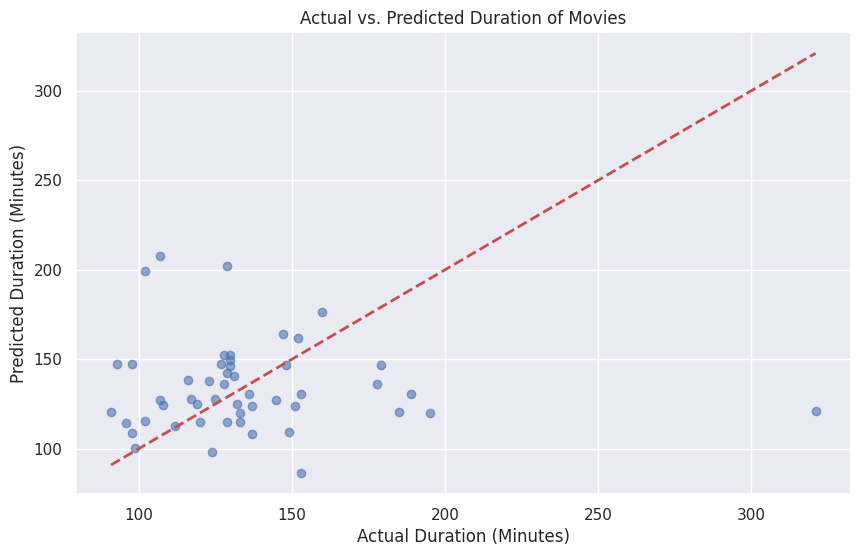

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Duration (Minutes)')
plt.ylabel('Predicted Duration (Minutes)')
plt.title('Actual vs. Predicted Duration of Movies')
plt.grid(True)
plt.show()

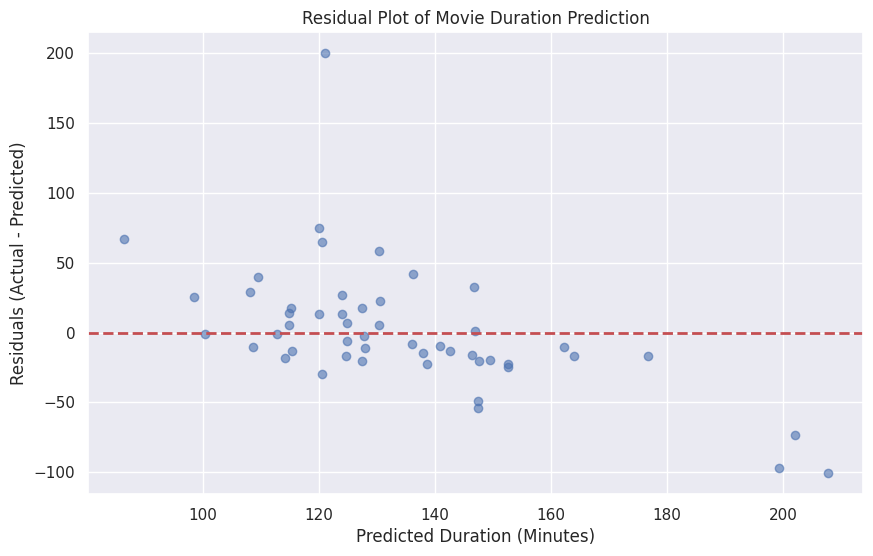

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Duration (Minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot of Movie Duration Prediction')
plt.grid(True)
plt.show()

# Thank You